# Understanding nn.Embedding and nn.Linear

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import torch
import torch.nn as nn

## Create the two tensor objects

In [2]:
vocab_size = 5000
embed_dim = int(vocab_size**(1/2))
print(f'{vocab_size:,} tokens in the vocab, and {embed_dim} embedding dimensions.')

5,000 tokens in the vocab, and 70 embedding dimensions.


In [3]:
E = nn.Embedding(vocab_size, embed_dim)
L = nn.Linear(embed_dim, vocab_size)

print(E)
print(L)
print(f'\nEmbedding matrix size: {E.weight.shape}')
print(f'Linear matrix size:    {L.weight.shape}')

Embedding(5000, 70)
Linear(in_features=70, out_features=5000, bias=True)

Embedding matrix size: torch.Size([5000, 70])
Linear matrix size:    torch.Size([5000, 70])


## Explore their attributes

In [4]:
len(dir(E)), len(dir(L))

(131, 125)

In [5]:
dir(E)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__constants__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_fill_padding_idx_with_zero',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_

In [6]:
# unique attributes of each type
attrE = dir(E)
attrL = dir(L)

print('Attributes in Embedding that are not in Linear:')
for e in attrE:
  if e not in attrL:
    print('  ' + e)


print('\n\nAttributes in Linear that are not in Embedding:')
for l in attrL:
  if l not in attrE:
    print('  ' + l)

Attributes in Embedding that are not in Linear:
  _fill_padding_idx_with_zero
  embedding_dim
  from_pretrained
  max_norm
  norm_type
  num_embeddings
  padding_idx
  scale_grad_by_freq
  sparse


Attributes in Linear that are not in Embedding:
  bias
  in_features
  out_features


## Indexing their vectors

In [7]:
print(E.weight)
print('')
print(L.weight)

Parameter containing:
tensor([[-0.8502,  0.8751, -0.9099,  ..., -0.8030,  0.2757, -0.6191],
        [-0.6323, -0.0277,  0.2203,  ..., -0.7526,  0.3444, -0.1200],
        [-0.2314, -1.0278, -0.8604,  ..., -0.2609,  1.6035,  0.5763],
        ...,
        [ 1.5593, -0.3996, -0.2403,  ..., -2.1285,  2.2052,  1.1446],
        [ 0.0304,  1.1548,  0.9349,  ..., -1.0494,  0.8058,  0.1252],
        [ 0.3716, -0.9184, -0.7433,  ...,  1.7644, -0.4115, -0.6183]],
       requires_grad=True)

Parameter containing:
tensor([[-0.0132, -0.0500, -0.0135,  ...,  0.0350, -0.0948,  0.0629],
        [-0.0801, -0.1127, -0.1161,  ..., -0.0435,  0.0671,  0.0412],
        [ 0.0974,  0.0023, -0.0777,  ..., -0.0179, -0.0148,  0.0852],
        ...,
        [ 0.0747, -0.0959,  0.0411,  ...,  0.0213,  0.0977, -0.0523],
        [ 0.0026, -0.1085,  0.0611,  ..., -0.0449, -0.0346, -0.0242],
        [-0.0803,  0.1032, -0.0345,  ...,  0.0015, -0.0930,  0.0767]],
       requires_grad=True)


In [9]:
tokenidx = torch.tensor([14])
E(tokenidx) # emulates one-hot encoding

tensor([[ 1.6600e+00,  7.9019e-01, -4.3265e-02,  9.8703e-01,  6.4352e-01,
         -1.2721e+00,  9.0723e-01, -4.3535e-01, -1.4071e-01,  1.4925e+00,
         -1.6735e-01, -1.4904e+00,  9.2171e-01, -1.1641e+00,  3.0921e-01,
         -3.6870e-01, -3.6557e-01, -3.6099e-01, -1.6351e+00, -5.4263e-01,
         -1.1511e+00,  2.0179e+00, -4.1120e-01, -9.7678e-01, -4.2804e-01,
          9.3417e-01, -5.2883e-01,  6.2143e-02,  1.3985e-01,  4.5117e-01,
         -1.4769e+00,  4.4502e-01, -5.2512e-01, -1.0351e+00, -7.2249e-01,
          8.4375e-02,  6.8829e-01, -2.3945e-01,  1.2861e+00, -2.6741e+00,
         -6.6019e-01,  1.3052e+00,  2.4540e-01, -1.0036e+00,  1.6329e+00,
          1.7369e+00,  4.5400e-01,  1.0099e+00,  7.5075e-01,  1.4983e-01,
          4.1792e-01, -1.3291e-02,  5.9722e-01, -2.4591e-01, -4.6407e-01,
         -1.2600e+00, -4.5662e-01,  1.9456e-01,  3.3380e-01, -1.8142e-01,
         -7.7938e-01, -3.4812e-04,  4.4538e-01, -1.7590e+00, -1.4334e+00,
          8.6927e-01, -4.7324e-01, -8.

In [11]:
# L(tokenidx)
L.weight[tokenidx, :]

tensor([[ 0.0459,  0.0841,  0.0569, -0.0413,  0.0458,  0.0825,  0.1130, -0.0168,
          0.0049, -0.1073,  0.0875,  0.0628,  0.0044, -0.0329, -0.0847,  0.0266,
          0.0771, -0.0021, -0.0518,  0.0086,  0.0480,  0.0893, -0.0577,  0.1018,
         -0.0495,  0.0865,  0.0342, -0.0520,  0.0061,  0.0284,  0.0100,  0.0245,
          0.0005,  0.0701,  0.0801, -0.0226, -0.0080, -0.0507, -0.0267,  0.0568,
         -0.0730, -0.0669, -0.1186,  0.0785,  0.0358,  0.0524,  0.0140, -0.0943,
         -0.1019,  0.1100, -0.0667,  0.0970,  0.1127, -0.0686, -0.1124,  0.1026,
         -0.0746, -0.0225,  0.0849,  0.1069,  0.0647,  0.1192, -0.0615,  0.0767,
         -0.0135, -0.0335, -0.1036,  0.0897, -0.1073, -0.0433]],
       grad_fn=<IndexBackward0>)

In [12]:
# explicit one-hot encoding with vector-matrix multiplication
one_hot_vector = torch.zeros(vocab_size, 1)
one_hot_vector[tokenidx] = 1

# as vector-matrix multiplication
one_hot_vector.t() @ L.weight

tensor([[ 0.0459,  0.0841,  0.0569, -0.0413,  0.0458,  0.0825,  0.1130, -0.0168,
          0.0049, -0.1073,  0.0875,  0.0628,  0.0044, -0.0329, -0.0847,  0.0266,
          0.0771, -0.0021, -0.0518,  0.0086,  0.0480,  0.0893, -0.0577,  0.1018,
         -0.0495,  0.0865,  0.0342, -0.0520,  0.0061,  0.0284,  0.0100,  0.0245,
          0.0005,  0.0701,  0.0801, -0.0226, -0.0080, -0.0507, -0.0267,  0.0568,
         -0.0730, -0.0669, -0.1186,  0.0785,  0.0358,  0.0524,  0.0140, -0.0943,
         -0.1019,  0.1100, -0.0667,  0.0970,  0.1127, -0.0686, -0.1124,  0.1026,
         -0.0746, -0.0225,  0.0849,  0.1069,  0.0647,  0.1192, -0.0615,  0.0767,
         -0.0135, -0.0335, -0.1036,  0.0897, -0.1073, -0.0433]],
       grad_fn=<MmBackward0>)

In [13]:
one_hot_vector.shape

torch.Size([5000, 1])

## Distributions of weights at initialization

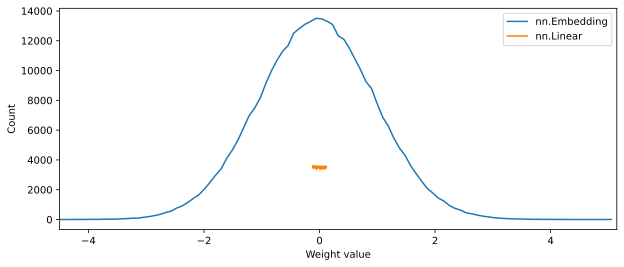

In [14]:
# extract histograms to get empirical distributions
Ey,Ex = np.histogram(E.weight.flatten().detach(),100)
Ly,Lx = np.histogram(L.weight.flatten().detach(),100)

plt.figure(figsize=(10,4))
plt.plot(Ex[:-1],Ey,label='nn.Embedding')
plt.plot(Lx[:-1],Ly,label='nn.Linear')

plt.gca().set(xlim=[np.min(Ex),np.max(Ex)],xlabel='Weight value',ylabel='Count')
plt.legend()
plt.show()

In [15]:
print('*** Statistics of nn.Linear weights ***\n')
print(f'Kaiming expected std: { np.sqrt(1/embed_dim)/np.sqrt(3) :.4f}')
print(f'Observed std of L: {torch.std(L.weight.detach()) :.4f}')

print(f'\nKaiming expected bounds: {np.sqrt(1/embed_dim):.4f}')
print(f'Observed min/max vals: [{torch.min(L.weight):.4f},{torch.max(L.weight):.4f}]')

*** Statistics of nn.Linear weights ***

Kaiming expected std: 0.0690
Observed std of L: 0.0691

Kaiming expected bounds: 0.1195
Observed min/max vals: [-0.1195,0.1195]


In [16]:
# repeat the above for Xavier
print('*** Statistics of nn.Embeddings weights ***\n')
print(f'Xavier expected std: { np.sqrt(2/(vocab_size+embed_dim)) :.4f}')
print(f'Observed std of E: {torch.std(E.weight.detach()) :.4f}') # it's normal, not Xavier

*** Statistics of nn.Embeddings weights ***

Xavier expected std: 0.0199
Observed std of E: 1.0011


In [17]:
# initialize L to match properties of E
Ln = nn.Linear(embed_dim, vocab_size) # new matrix to avoid overwriting
torch.nn.init.normal_(Ln.weight)

Parameter containing:
tensor([[-0.5215,  0.1648, -0.5726,  ..., -0.5255,  0.7305, -2.7864],
        [ 0.2712,  0.8455,  1.0253,  ...,  1.0432,  1.5014, -0.8329],
        [ 0.0190, -0.7744,  1.0726,  ..., -0.3460, -2.2644, -0.2600],
        ...,
        [-0.3287,  0.0113,  0.7150,  ...,  1.0755,  0.7246,  0.0263],
        [ 0.4215, -0.4331, -0.9630,  ..., -0.8838,  1.8473,  2.7763],
        [ 0.1468, -0.3010, -1.4817,  ..., -1.2139, -0.2284,  0.2855]],
       requires_grad=True)

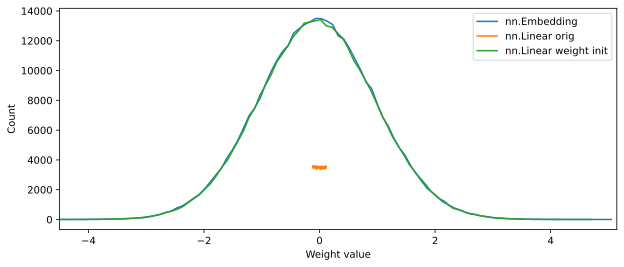

In [18]:
Lny,Lnx = np.histogram(Ln.weight.flatten().detach(),100)

plt.figure(figsize=(10,4))
plt.plot(Ex[:-1],Ey,label='nn.Embedding')
plt.plot(Lx[:-1],Ly,label='nn.Linear orig')
plt.plot(Lnx[:-1],Lny,label='nn.Linear weight init')

plt.gca().set(xlim=[np.min(Ex),np.max(Ex)],xlabel='Weight value',ylabel='Count')
plt.legend()
plt.show()

In [19]:
# Conclusions:
#   1) Embeddings weights are initialized as standard normal, not Xavier normal.
#   2) they are "different" for practical reasons but reflect the same thing (trainable random weights)